# 1. *Import Required libraries*


In [152]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [148]:
sns.set(style="whitegrid")


# 2. *Load The Dataset*


In [157]:
df = pd.read_csv("cleaned_train.csv")

# 3. *Initial Data Exploration*



In [104]:
df.info()              # Check data types and null

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          891 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Embarked     891 non-null    object 
 9   Title        891 non-null    object 
dtypes: float64(2), int64(5), object(3)
memory usage: 69.7+ KB


In [105]:
df.describe()          # Summary statistics

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [106]:
df.isnull().sum()      # Missing values

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
Title          0
dtype: int64

In [107]:
df.head()              # Preview first few rows

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,1,0,3,male,22.0,1,0,7.2500,S,Mr
1,2,1,1,female,38.0,1,0,71.2833,C,Mrs
2,3,1,3,female,26.0,0,0,7.9250,S,Miss
3,4,1,1,female,35.0,1,0,53.1000,S,Mrs
4,5,0,3,male,35.0,0,0,8.0500,S,Mr


# 4. *Value counts for categorical features*


In [169]:
df['Sex'].value_counts()
df['Embarked'].value_counts()
df['Pclass'].value_counts()
df['Title'].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: count, dtype: int64

# 5. *Univariate Analysis (Single Column)*

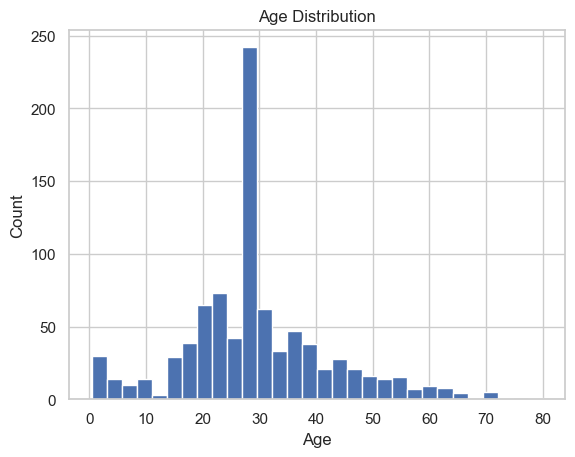

In [110]:
# a. Histogram
df['Age'].hist(bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

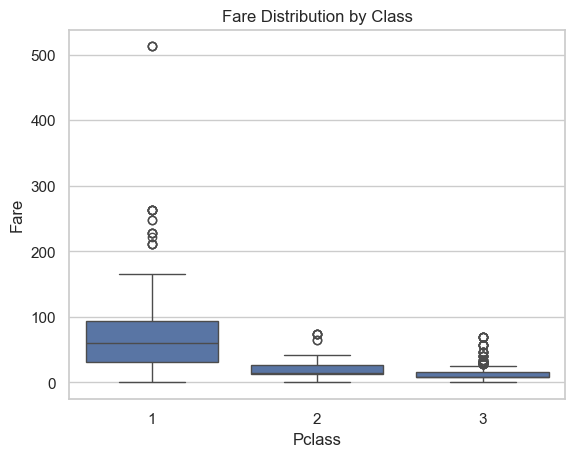

In [111]:
# b. Boxplot
sns.boxplot(x='Pclass', y='Fare', data=df)
plt.title("Fare Distribution by Class")
plt.show()

# 6. *Bivariate/Multivariate Analysis*

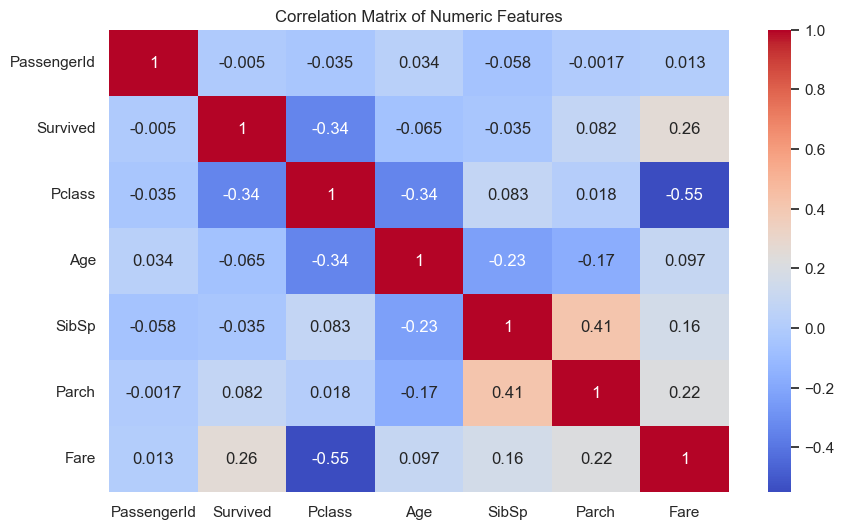

In [113]:
 # a. Correlation Heatmap
# Only select numeric columns for correlation
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Plot correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Numeric Features")
plt.show()

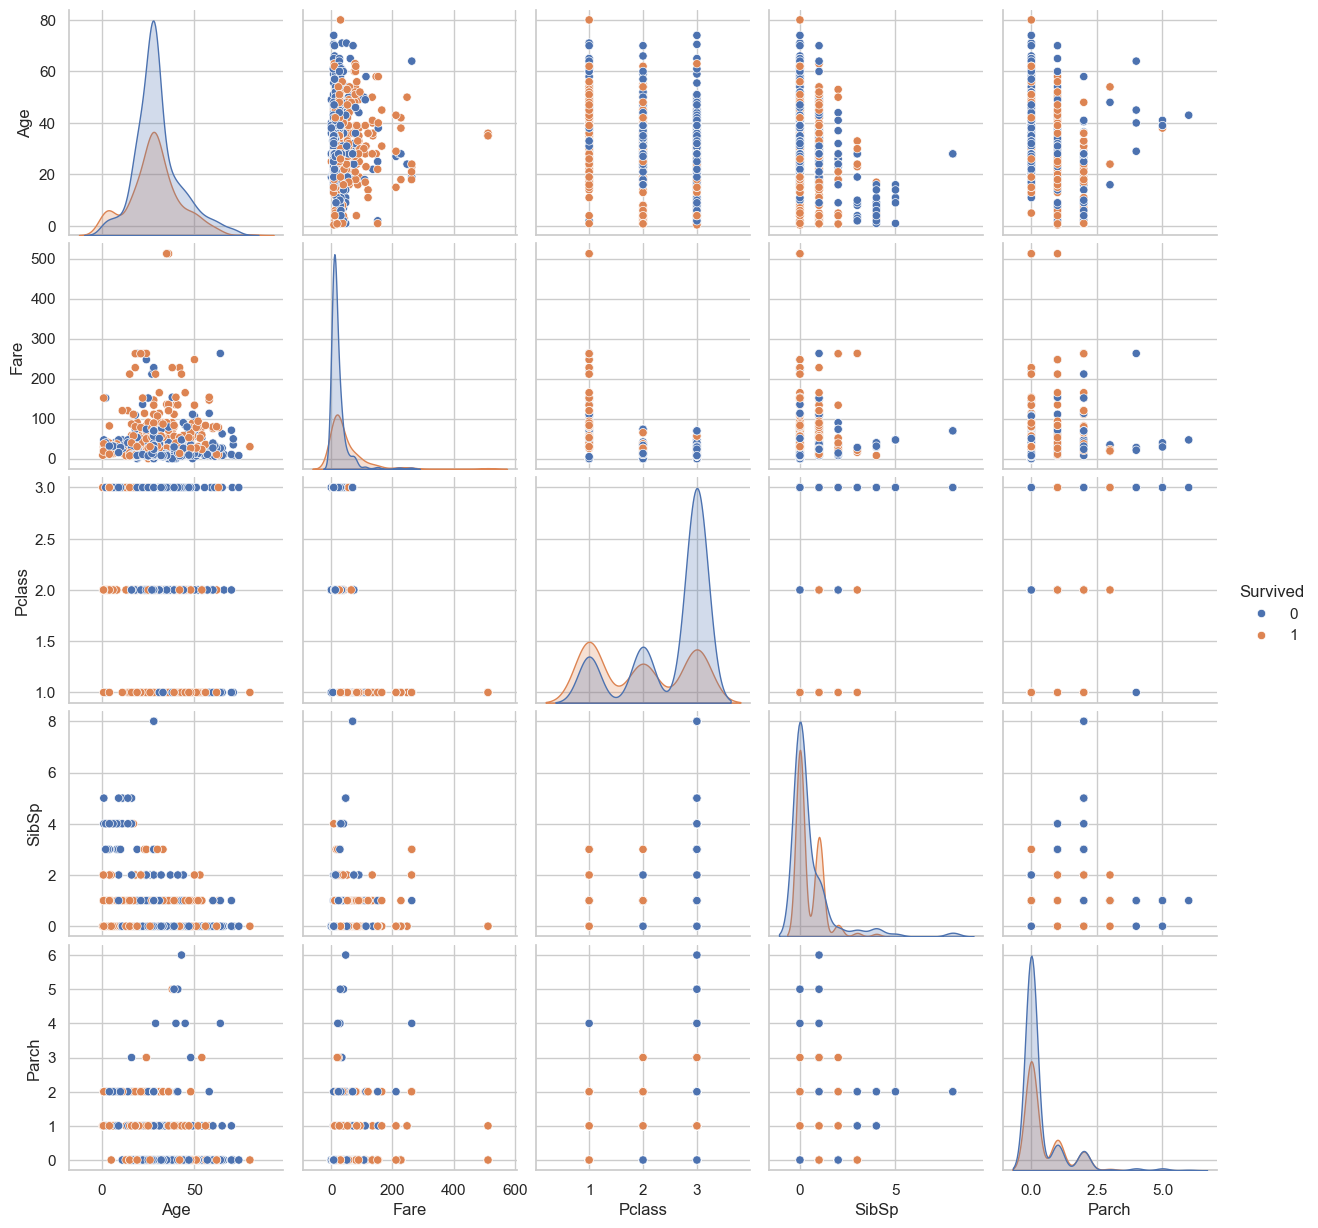

In [114]:
# b. Pairplot
sns.pairplot(df, hue='Survived', vars=['Age', 'Fare', 'Pclass', 'SibSp', 'Parch'])
plt.show()

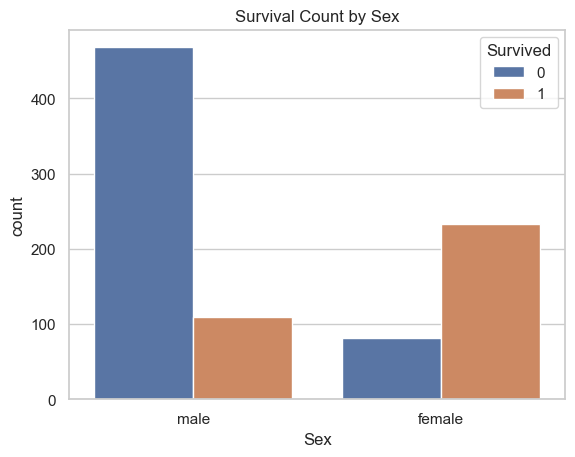

In [140]:
# c. Countplots (Categorical vs Survived)
# a)
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival Count by Sex")
plt.show()


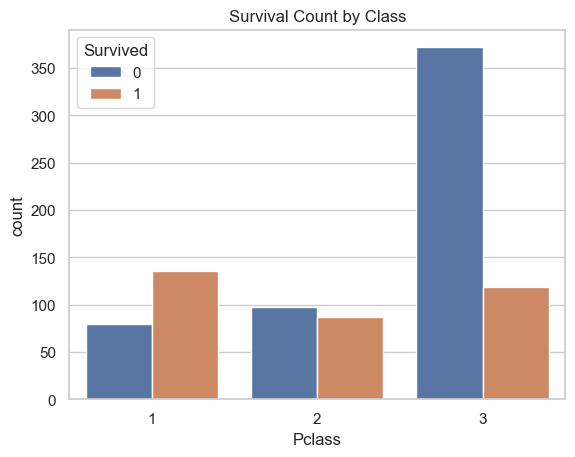

In [142]:
# b )
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Survival Count by Class")
plt.show()

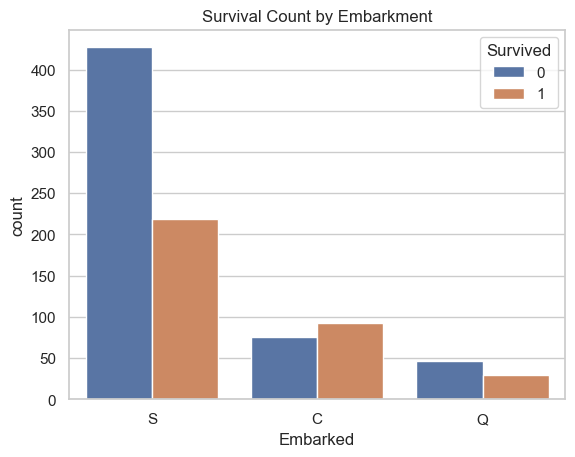

In [144]:
# c )
sns.countplot(x='Embarked', hue='Survived', data=df)
plt.title("Survival Count by Embarkment")
plt.show()

# 7. *Fancy Visuals*


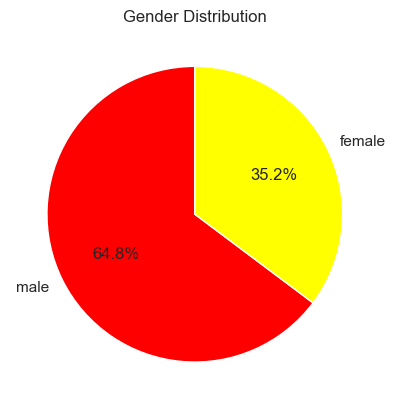

In [178]:
df['Sex'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['red','yellow'])
plt.title("Gender Distribution")
plt.ylabel('')
plt.show()

Gender and Survival
- Females had a significantly higher survival rate compared to males.
- This supports the "women and children first" evacuation protocol.

####  Passenger Class (Pclass)
- 1st class passengers had the highest survival rate.
- 3rd class passengers faced the lowest survival rate.
- Socioeconomic status clearly impacted access to lifeboats and safety.

#### Embarkation Port
- Passengers from Cherbourg (C) had a higher chance of survival.
- Majority embarked from Southampton (S), where survival was relatively lower.

#### Age Distribution
- Most passengers were between 20–40 years old.
- Children under 10 had a better survival rate than older age groups.

#### Fare Insights
- Survivors generally paid higher fares.
- High-fare tickets were linked to better accommodation and quicker access to lifeboats.

#### Family Features (SibSp, Parch)
- Passengers with 1 or 2 family members onboard had better survival rates.
- Being alone or having too many dependents reduced chances of survival.

#### Title Feature (Mr, Miss, Mrs, etc.)
- Titles added valuable insight:
- Miss and Mrs had higher survival rates.
- Mr had the lowest, aligning with male survival statistics.

### Correlation Findings:
- Survived was positively correlated with:
- `Fare`, `Sex` (when encoded), and `Pclass` (inversely).
- `SibSp` and `Parch` showed minor correlations.
- Categorical variables like `Sex` and `Title` were highly predictive after encoding.
